# Customer Segmentation using K-Means Clustering

**Goal:** Group customers into distinct segments based on their purchasing behavior and demographic characteristics, using unsupervised machine learning (K-Means clustering).

**Tech Stack:** Python · Pandas · NumPy · Scikit-learn · Matplotlib · Seaborn

**Dataset:** Mall Customer Segmentation Data (200 customers — Age, Annual Income, Spending Score)

**Skills demonstrated:** Exploratory Data Analysis, Feature Scaling, Unsupervised Learning, K-Means Clustering, Data Visualization, Customer Profiling


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load the Dataset

This notebook uses the classic **Mall Customer Segmentation** dataset structure (`CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`).

> If you have the real Kaggle CSV, just replace this cell with:
> `df = pd.read_csv("Mall_Customers.csv")`
>
> Below, a dataset with the same shape and realistic distributions is generated so the notebook runs end-to-end out of the box.

In [2]:
np.random.seed(42)
n = 200

# Simulate realistic customer segments (age, income, spending score)
segments = [
    {"n": 40, "age": (18, 35), "income": (15, 40), "spend": (60, 95)},   # Young, low income, high spenders
    {"n": 40, "age": (25, 45), "income": (60, 100), "spend": (55, 90)},  # High income, high spenders
    {"n": 40, "age": (30, 55), "income": (60, 100), "spend": (5, 40)},   # High income, low spenders
    {"n": 40, "age": (35, 65), "income": (15, 45), "spend": (5, 40)},    # Low income, low spenders
    {"n": 40, "age": (25, 50), "income": (40, 60), "spend": (40, 60)},   # Average across the board
]

rows = []
cid = 1
for seg in segments:
    for _ in range(seg["n"]):
        age = np.random.randint(*seg["age"])
        income = np.random.randint(*seg["income"])
        spend = np.random.randint(*seg["spend"])
        gender = np.random.choice(["Male", "Female"])
        rows.append([cid, gender, age, income, spend])
        cid += 1

df = pd.DataFrame(rows, columns=["CustomerID", "Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,96,Male,31,61,36
1,16,Female,23,36,63
2,31,Male,20,15,94
3,159,Female,53,43,31
4,129,Female,36,33,11


## 3. Exploratory Data Analysis

In [3]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,37.895000,53.930000,48.875000
std,57.879185,10.862502,25.226713,25.351387
min,1.000000,18.000000,15.000000,5.000000
25%,50.750000,29.000000,33.000000,26.000000
50%,100.500000,38.000000,52.000000,49.000000
75%,150.250000,46.000000,77.250000,73.000000
max,200.000000,63.000000,99.000000,94.000000


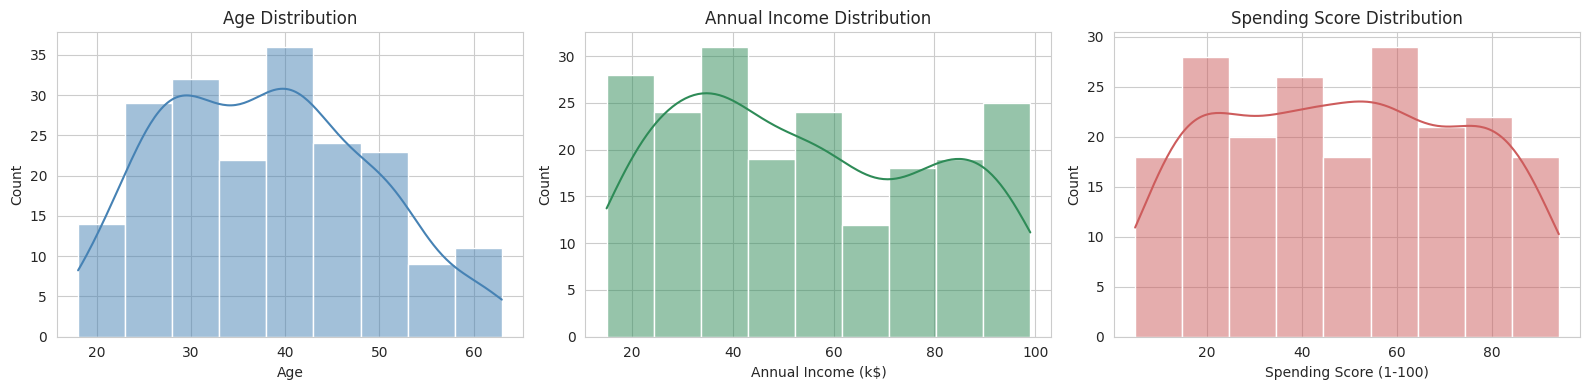

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["Age"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution")

sns.histplot(df["Annual Income (k$)"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Annual Income Distribution")

sns.histplot(df["Spending Score (1-100)"], kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Spending Score Distribution")

plt.tight_layout()
plt.show()


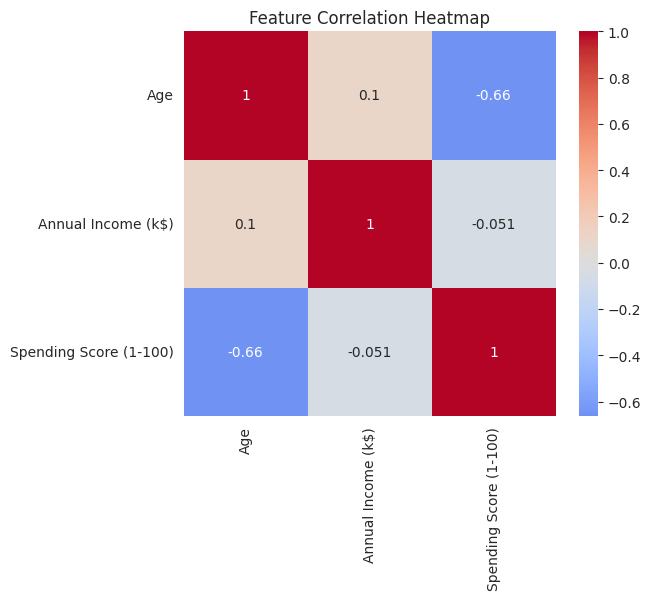

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr(),
            annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


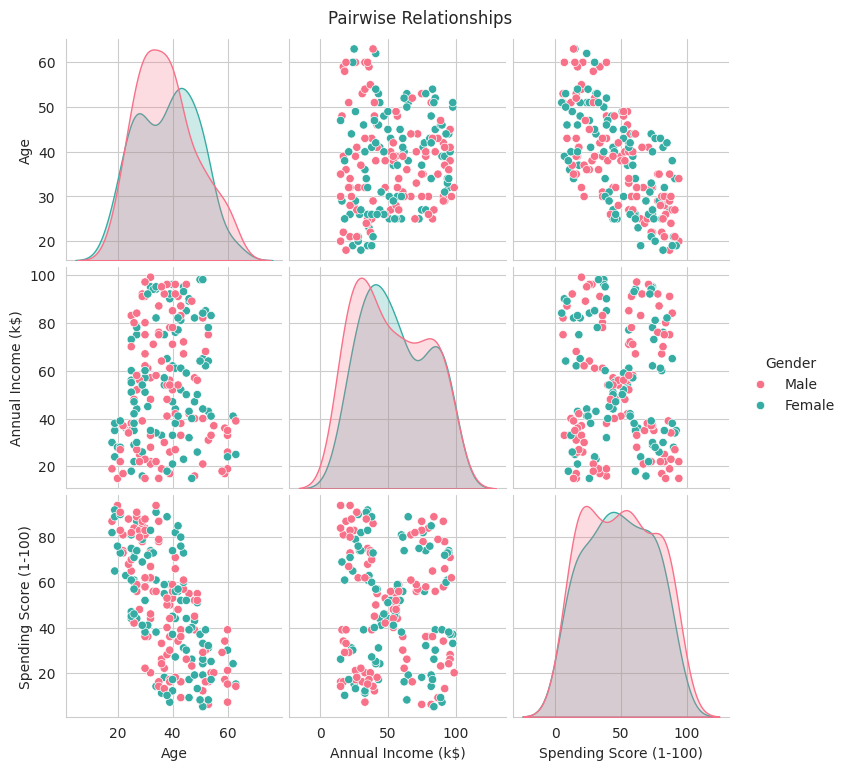

In [6]:
sns.pairplot(df, vars=["Age", "Annual Income (k$)", "Spending Score (1-100)"], hue="Gender", palette="husl")
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()


## 4. Feature Selection & Scaling

We cluster on **Annual Income** and **Spending Score** (the classic 2D view), then extend to a 3-feature version including **Age**. K-Means is distance-based, so features must be scaled first.

In [7]:
features_2d = df[["Annual Income (k$)", "Spending Score (1-100)"]]
features_3d = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
scaled_2d = scaler.fit_transform(features_2d)
scaled_3d = StandardScaler().fit_transform(features_3d)


## 5. Finding the Optimal Number of Clusters

Using the **Elbow Method** (inertia) and **Silhouette Score** to pick k.

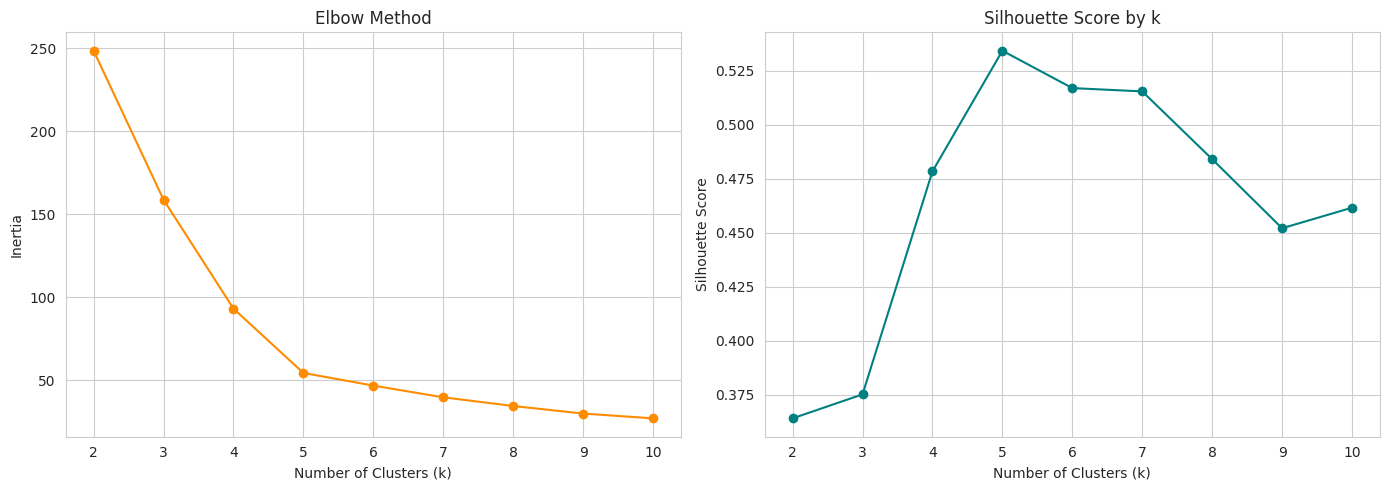

Best k by silhouette score: 5


In [8]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_2d)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_2d, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, marker="o", color="darkorange")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, sil_scores, marker="o", color="teal")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k = K_range[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")


## 6. Fit K-Means & Assign Segments

In [9]:
k = 5  # chosen from elbow/silhouette analysis above
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_2d)

print(f"Silhouette Score (k={k}): {silhouette_score(scaled_2d, df['Cluster']):.3f}")
df["Cluster"].value_counts().sort_index()


Silhouette Score (k=5): 0.534


Cluster
0    37
1    39
2    46
3    39
4    39
Name: count, dtype: int64

## 7. Visualize the Segments

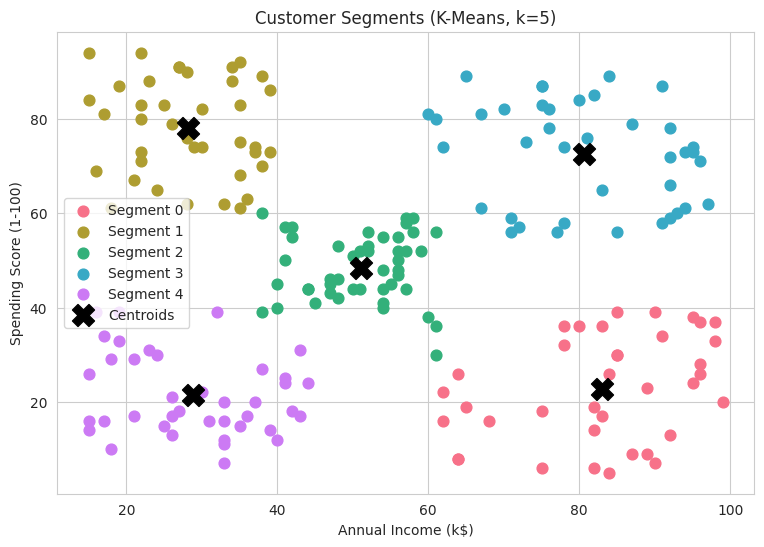

In [10]:
plt.figure(figsize=(9, 6))
palette = sns.color_palette("husl", k)

for cluster_id in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == cluster_id]
    plt.scatter(subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
                s=60, color=palette[cluster_id], label=f"Segment {cluster_id}")

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], s=250, c="black", marker="X", label="Centroids")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments (K-Means, k=5)")
plt.legend()
plt.show()


## 8. Customer Profiling

Summarize each segment's average characteristics to give the clusters business meaning.

In [11]:
profile = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
profile["Count"] = df["Cluster"].value_counts().sort_index()
profile


,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,44.4,83.0,22.8,37
1,25.4,28.1,78.1,39
2,36.5,51.1,48.3,46
3,34.8,80.6,72.5,39
4,48.9,28.8,21.4,39


In [12]:
labels_map = {}
for cid, row in profile.iterrows():
    income, spend = row["Annual Income (k$)"], row["Spending Score (1-100)"]
    if income >= 55 and spend >= 55:
        label = "High Income, High Spenders (Target segment)"
    elif income >= 55 and spend < 55:
        label = "High Income, Low Spenders (Careful/Price-sensitive)"
    elif income < 55 and spend >= 55:
        label = "Low Income, High Spenders (Impulsive)"
    elif income < 55 and spend < 55:
        label = "Low Income, Low Spenders (Budget-conscious)"
    else:
        label = "Average Income, Average Spenders"
    labels_map[cid] = label

profile["Segment Label"] = profile.index.map(labels_map)
profile


,Age,Annual Income (k$),Spending Score (1-100),Count,Segment Label
Cluster,,,,,
0,44.4,83.0,22.8,37,"High Income, Low Spenders (Careful/Price-sensi..."
1,25.4,28.1,78.1,39,"Low Income, High Spenders (Impulsive)"
2,36.5,51.1,48.3,46,"Low Income, Low Spenders (Budget-conscious)"
3,34.8,80.6,72.5,39,"High Income, High Spenders (Target segment)"
4,48.9,28.8,21.4,39,"Low Income, Low Spenders (Budget-conscious)"


## 9. Key Takeaways

- Customers naturally group into **5 distinct segments** based on income and spending behavior.
- The **"High Income, High Spenders"** segment is the highest-value target for premium campaigns and loyalty programs.
- **"Low Income, High Spenders"** customers may respond well to promotions and installment offers.
- **"High Income, Low Spenders"** customers represent untapped potential — worth targeted engagement to understand why they aren't spending more.
- This kind of segmentation lets a business move from one-size-fits-all marketing to **targeted, personalized campaigns**, improving ROI on marketing spend.

### Resume Impact
This project demonstrates: unsupervised learning (K-Means), feature scaling, hyperparameter selection (elbow method + silhouette score), exploratory data analysis, and translating a model's output into actionable business insight — a full data science workflow from raw data to business recommendation.